# Telco Customer Churn: comparación PyCaret vs. scikit-learn

**Asignatura:** Ciencia de Datos  
**Integrantes:** David Célleri, José Solórzano

Este notebook compara los dos enfoques del proyecto para responder la pregunta de la propuesta:

> ¿Puede PyCaret igualar o superar el desempeño de una regresión logística hecha a mano en
> scikit-learn al predecir el abandono de clientes, y con qué costo en tiempo y esfuerzo de programación?

| Enfoque | Modelo | Origen |
|---|---|---|
| PyCaret (AutoML) | Gradient Boosting Classifier, el mejor de `compare_models()` | `pipeline_churn.ipynb` |
| scikit-learn (manual) | Regresión logística | `baseline_sklearn.ipynb` |

### Cómo se trata la incertidumbre

Las métricas de un modelo cambian según qué datos se usen para entrenar y evaluar, así que cada
valor tiene un margen de error. Una diferencia entre modelos solo se considera real si su
**intervalo de confianza del 95% no incluye el 0**. Se usan dos fuentes de evidencia:

1. **Validación cruzada repetida** (5 folds × 10 repeticiones, mismos folds para ambos modelos)
   sobre el conjunto de entrenamiento, con el *t-test* corregido de Nadeau y Bengio (2003), que
   ajusta por el solapamiento entre folds.
2. **Bootstrap pareado** (2.000 remuestreos) sobre el conjunto de prueba del 20%, que mide cuánto
   variarían las métricas con otra muestra de clientes del mismo tamaño.

## 1. Datos y partición

Se reconstruye el experimento de PyCaret con la misma configuración que en `pipeline_churn.ipynb`
y se verifica que la partición coincide con la guardada en `data/particion_train_test.csv`, que
también usa la línea base.

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pycaret.classification import ClassificationExperiment
from scipy import stats
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

SEMILLA = 42
DATA_DIR = Path("data")
COLOR_PYCARET, COLOR_SKLEARN = "#2a78d6", "#eb6834"
METRICAS = ["AUC", "F1", "Recall"]

df = pd.read_csv(DATA_DIR / "telco_churn_clean.csv")
NUMERICAS = ["tenure", "MonthlyCharges", "TotalCharges"]
CATEGORICAS = [c for c in df.columns if c not in NUMERICAS + ["Churn"]]

exp = ClassificationExperiment()
exp.setup(
    data=df,
    target="Churn",
    train_size=0.8,
    data_split_stratify=True,
    fold_strategy="stratifiedkfold",
    fold=5,
    numeric_features=NUMERICAS,
    categorical_features=CATEGORICAS,
    normalize=True,
    normalize_method="zscore",
    session_id=SEMILLA,
    verbose=False,
)

X_train, X_test = exp.get_config("X_train"), exp.get_config("X_test")
y_train, y_test = exp.get_config("y_train"), exp.get_config("y_test")

particion = pd.read_csv(DATA_DIR / "particion_train_test.csv")
assert set(particion.query("conjunto == 'train'")["indice"]) == set(X_train.index)
assert set(particion.query("conjunto == 'test'")["indice"]) == set(X_test.index)
print(f"Partición verificada: {len(X_train):,} entrenamiento / {len(X_test):,} prueba")

Partición verificada: 5,634 entrenamiento / 1,409 prueba


## 2. Los dos modelos

- **PyCaret:** el pipeline de preprocesamiento que genera `setup()` (imputación, codificación
  ordinal y *one-hot*, *z-score*) seguido del Gradient Boosting con los parámetros por defecto
  con los que ganó en `compare_models()`.
- **scikit-learn:** el mismo pipeline de `baseline_sklearn.ipynb` (`StandardScaler` +
  `OneHotEncoder(drop="first")` + `LogisticRegression`).

Ambos se construyen como pipelines sin entrenar, para poder evaluarlos exactamente sobre los
mismos folds.

In [2]:
modelo_pycaret = clone(exp.get_config("pipeline"))
modelo_pycaret.steps.append(("model", GradientBoostingClassifier(random_state=SEMILLA)))

modelo_sklearn = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), NUMERICAS),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CATEGORICAS),
    ])),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEMILLA)),
])

MODELOS = {"PyCaret (Gradient Boosting)": modelo_pycaret,
           "scikit-learn (Reg. logística)": modelo_sklearn}
SCORING = {"AUC": "roc_auc", "F1": "f1", "Recall": "recall"}

### 2.1 Comprobación: se reproducen los resultados originales

Con los 5 folds originales de PyCaret (estratificados, sin *shuffle*), el Gradient Boosting debe
dar las mismas métricas que en `pipeline_churn.ipynb` (AUC 0,8468). Así se confirma que el modelo
evaluado aquí es el mismo.

La línea base usó otros folds (`shuffle=True`), por eso sus valores aquí cambian levemente
respecto a su notebook (AUC 0,8459). A partir de ahora ambos modelos se evalúan siempre con los
mismos folds.

In [3]:
cv_original = StratifiedKFold(n_splits=5)
filas = []
for nombre, modelo in MODELOS.items():
    r = cross_validate(modelo, X_train, y_train, cv=cv_original, scoring=SCORING)
    filas.append({"Modelo": nombre, **{m: r[f"test_{m}"].mean() for m in METRICAS}})
pd.DataFrame(filas).set_index("Modelo").round(4)

,AUC,F1,Recall
Modelo,,,
PyCaret (Gradient Boosting),0.8468,0.5856,0.5278
scikit-learn (Reg. logística),0.8457,0.5977,0.5478


## 3. Validación cruzada repetida con intervalos de confianza

Con solo 5 folds la estimación es inestable: entre folds el AUC varía alrededor de ±0,01 y el
recall alrededor de ±0,03. Para tener una estimación más confiable se repite la validación cruzada
10 veces con distintos cortes (50 evaluaciones por modelo), siempre con los mismos folds para
ambos modelos. Esto permite comparar **fold a fold** (comparación pareada).

Como los folds comparten datos de entrenamiento, las 50 evaluaciones no son independientes y la
desviación estándar simple subestima la incertidumbre. El *t-test* corregido de Nadeau y Bengio
infla la varianza con el factor $\frac{1}{n} + \frac{n_{prueba}}{n_{entrenamiento}}$ para compensarlo.

In [4]:
cv_repetida = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEMILLA)
N_EVAL = cv_repetida.get_n_splits()
RATIO = 1 / 4  # tamaño de prueba / entrenamiento en cada fold de 5-fold CV

inicio = time.perf_counter()
cv_res = {
    nombre: cross_validate(modelo, X_train, y_train, cv=cv_repetida, scoring=SCORING, n_jobs=-1)
    for nombre, modelo in MODELOS.items()
}
print(f"{N_EVAL} evaluaciones por modelo en {time.perf_counter() - inicio:.1f} s")


def ic_corregido(valores, confianza=0.95):
    """Media e IC con la varianza corregida de Nadeau y Bengio."""
    n = len(valores)
    error = np.sqrt((1 / n + RATIO) * np.var(valores, ddof=1))
    t = stats.t.ppf((1 + confianza) / 2, n - 1)
    media = np.mean(valores)
    p_valor = 2 * stats.t.sf(abs(media / error), n - 1) if error > 0 else np.nan
    return media, media - t * error, media + t * error, p_valor


filas = []
for nombre in MODELOS:
    for m in METRICAS:
        media, bajo, alto, _ = ic_corregido(cv_res[nombre][f"test_{m}"])
        filas.append({"Modelo": nombre, "Métrica": m, "Media": media,
                      "IC 95% inferior": bajo, "IC 95% superior": alto})
tabla_cv = pd.DataFrame(filas)
tabla_cv.pivot(index="Métrica", columns="Modelo", values="Media").round(4)

50 evaluaciones por modelo en 17.4 s


Modelo,PyCaret (Gradient Boosting),scikit-learn (Reg. logística)
Métrica,,
AUC,0.8471,0.8457
F1,0.5868,0.5956
Recall,0.5259,0.5465


In [5]:
tabla_cv.round(4)

,Modelo,Métrica,Media,IC 95% inferior,IC 95% superior
0,PyCaret (Gradient Boosting),AUC,0.8471,0.8346,0.8596
1,PyCaret (Gradient Boosting),F1,0.5868,0.5617,0.6119
2,PyCaret (Gradient Boosting),Recall,0.5259,0.4951,0.5567
3,scikit-learn (Reg. logística),AUC,0.8457,0.8345,0.8568
4,scikit-learn (Reg. logística),F1,0.5956,0.5744,0.6168
5,scikit-learn (Reg. logística),Recall,0.5465,0.5175,0.5755


### 3.1 Diferencia pareada (PyCaret − scikit-learn)

Lo que importa no es si los intervalos de cada modelo se solapan, sino el intervalo de la
**diferencia** calculada fold a fold. Si incluye el 0, no hay evidencia de que un modelo sea mejor.

In [6]:
nombre_pc, nombre_sk = MODELOS.keys()
filas = []
for m in METRICAS:
    dif = cv_res[nombre_pc][f"test_{m}"] - cv_res[nombre_sk][f"test_{m}"]
    media, bajo, alto, p = ic_corregido(dif)
    filas.append({"Métrica": m, "Diferencia": media, "IC 95% inferior": bajo,
                  "IC 95% superior": alto, "p-valor": p,
                  "¿Diferencia significativa?": "Sí" if bajo > 0 or alto < 0 else "No"})
dif_cv = pd.DataFrame(filas).set_index("Métrica")
dif_cv.round(4)

,Diferencia,IC 95% inferior,IC 95% superior,p-valor,¿Diferencia significativa?
Métrica,,,,,
AUC,0.0014,-0.0031,0.0060,0.5323,No
F1,-0.0088,-0.0281,0.0104,0.3603,No
Recall,-0.0206,-0.0440,0.0028,0.0827,No


## 4. Conjunto de prueba con bootstrap

Cada modelo se entrena con todo el conjunto de entrenamiento y se evalúa en el 20% de prueba
(1.409 clientes, de los cuales 374 abandonan). Como el conjunto de prueba es una sola muestra, se
remuestrea 2.000 veces con reemplazo para estimar el margen de error. En cada remuestreo se evalúan
**los dos modelos sobre los mismos clientes**, así que la diferencia también es pareada.

El umbral de decisión es 0,5 en ambos modelos (el valor por defecto en ambas herramientas).

In [7]:
probabilidades = {}
tiempos_fit = {}
for nombre, modelo in MODELOS.items():
    inicio = time.perf_counter()
    modelo.fit(X_train, y_train)
    tiempos_fit[nombre] = time.perf_counter() - inicio
    probabilidades[nombre] = modelo.predict_proba(X_test)[:, 1]

y_true = y_test.to_numpy()


def calcular_metricas(y, prob, umbral=0.5):
    pred = (prob >= umbral).astype(int)
    return {"AUC": roc_auc_score(y, prob), "F1": f1_score(y, pred), "Recall": recall_score(y, pred)}


puntuales = {nombre: calcular_metricas(y_true, p) for nombre, p in probabilidades.items()}

N_BOOT = 2000
rng = np.random.default_rng(SEMILLA)
boot = {nombre: {m: [] for m in METRICAS} for nombre in MODELOS}
for _ in range(N_BOOT):
    idx = rng.integers(0, len(y_true), len(y_true))
    for nombre, p in probabilidades.items():
        for m, v in calcular_metricas(y_true[idx], p[idx]).items():
            boot[nombre][m].append(v)
boot = {nombre: {m: np.array(v) for m, v in d.items()} for nombre, d in boot.items()}

filas = []
for nombre in MODELOS:
    for m in METRICAS:
        bajo, alto = np.percentile(boot[nombre][m], [2.5, 97.5])
        filas.append({"Modelo": nombre, "Métrica": m, "Valor": puntuales[nombre][m],
                      "IC 95% inferior": bajo, "IC 95% superior": alto})
tabla_test = pd.DataFrame(filas)
tabla_test.round(4)

,Modelo,Métrica,Valor,IC 95% inferior,IC 95% superior
0,PyCaret (Gradient Boosting),AUC,0.8434,0.8197,0.8645
1,PyCaret (Gradient Boosting),F1,0.5813,0.5344,0.6230
2,PyCaret (Gradient Boosting),Recall,0.5160,0.4659,0.5646
3,scikit-learn (Reg. logística),AUC,0.8422,0.8186,0.8635
4,scikit-learn (Reg. logística),F1,0.6049,0.5583,0.6463
5,scikit-learn (Reg. logística),Recall,0.5588,0.5054,0.6089


In [8]:
filas = []
for m in METRICAS:
    dif = boot[nombre_pc][m] - boot[nombre_sk][m]
    bajo, alto = np.percentile(dif, [2.5, 97.5])
    filas.append({"Métrica": m, "Diferencia": puntuales[nombre_pc][m] - puntuales[nombre_sk][m],
                  "IC 95% inferior": bajo, "IC 95% superior": alto,
                  "¿Diferencia significativa?": "Sí" if bajo > 0 or alto < 0 else "No"})
dif_test = pd.DataFrame(filas).set_index("Métrica")
dif_test.round(4)

,Diferencia,IC 95% inferior,IC 95% superior,¿Diferencia significativa?
Métrica,,,,
AUC,0.0012,-0.0061,0.0085,No
F1,-0.0236,-0.0544,0.0066,No
Recall,-0.0428,-0.0784,-0.0079,Sí


## 5. Visualización de los resultados

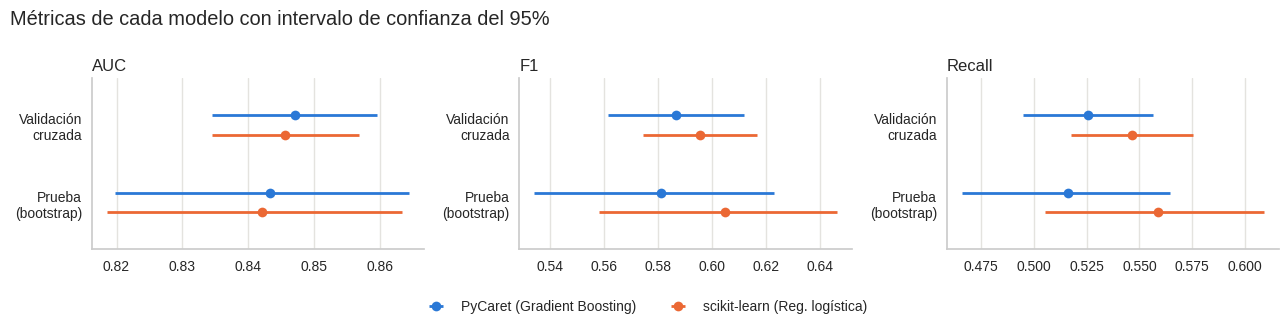

In [9]:
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "axes.axisbelow": True})

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, m in zip(axes, METRICAS):
    for j, (fuente, tabla, col) in enumerate([("Validación cruzada", tabla_cv, "Media"),
                                              ("Prueba (bootstrap)", tabla_test, "Valor")]):
        for k, (nombre, color) in enumerate(zip(MODELOS, [COLOR_PYCARET, COLOR_SKLEARN])):
            fila = tabla[(tabla["Modelo"] == nombre) & (tabla["Métrica"] == m)].iloc[0]
            y_pos = j + (k - 0.5) * 0.25
            ax.errorbar(fila[col], y_pos,
                        xerr=[[fila[col] - fila["IC 95% inferior"]], [fila["IC 95% superior"] - fila[col]]],
                        fmt="o", color=color, markersize=7, capsize=3, linewidth=2,
                        label=nombre if j == 0 else None)
    ax.set_yticks([0, 1], ["Validación\ncruzada", "Prueba\n(bootstrap)"])
    ax.set_ylim(-0.6, 1.6)
    ax.invert_yaxis()
    ax.set_title(m, loc="left")
    ax.grid(axis="y", visible=False)
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, loc="lower center", ncol=2)
fig.suptitle("Métricas de cada modelo con intervalo de confianza del 95%", x=0.01, ha="left")
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

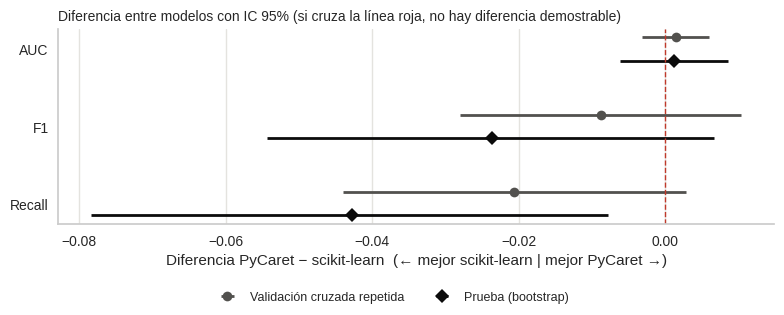

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.2))
for j, (fuente, tabla, marcador) in enumerate([("Validación cruzada repetida", dif_cv, "o"),
                                               ("Prueba (bootstrap)", dif_test, "D")]):
    for i, m in enumerate(METRICAS):
        fila = tabla.loc[m]
        ax.errorbar(fila["Diferencia"], i + (j - 0.5) * 0.3,
                    xerr=[[fila["Diferencia"] - fila["IC 95% inferior"]],
                          [fila["IC 95% superior"] - fila["Diferencia"]]],
                    fmt=marcador, color="#52514e" if j == 0 else "#0b0b0b", markersize=7,
                    capsize=3, linewidth=2, label=fuente if i == 0 else None)
ax.axvline(0, color="#c0392b", linewidth=1, linestyle="--")
ax.set_yticks(range(len(METRICAS)), METRICAS)
ax.invert_yaxis()
ax.set_xlabel("Diferencia PyCaret − scikit-learn  (← mejor scikit-learn | mejor PyCaret →)")
ax.set_title("Diferencia entre modelos con IC 95% (si cruza la línea roja, no hay diferencia demostrable)",
             loc="left", fontsize=10)
ax.grid(axis="y", visible=False)
fig.legend(*ax.get_legend_handles_labels(), frameon=False, loc="lower center", ncol=2, fontsize=9)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## 6. Tiempo y líneas de código

Para medir el esfuerzo de programación se escribe el **código mínimo** que necesita cada enfoque
para llegar desde el dataset limpio hasta un modelo entrenado y evaluado con validación cruzada.
El código se ejecuta realmente, de modo que lo que se cuenta y se cronometra es código que funciona.
Se cuentan las líneas no vacías, incluidas las importaciones.

In [11]:
CODIGO_PYCARET = """
from pycaret.classification import ClassificationExperiment
exp_min = ClassificationExperiment()
exp_min.setup(data=df, target="Churn", train_size=0.8, fold=5, normalize=True,
              session_id=42, verbose=False)
modelo_min = exp_min.compare_models(sort="AUC", verbose=False)
"""

CODIGO_SKLEARN = """
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
X, y = df.drop(columns="Churn"), df["Churn"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)
num = ["tenure", "MonthlyCharges", "TotalCharges"]
cat = [c for c in X.columns if c not in num]
prep = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat),
])
modelo_min = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=1000))])
cv_min = cross_validate(modelo_min, X_tr, y_tr, cv=StratifiedKFold(5),
                        scoring=["roc_auc", "f1", "recall"])
modelo_min.fit(X_tr, y_tr)
"""

filas = []
for nombre, codigo in [(nombre_pc, CODIGO_PYCARET), (nombre_sk, CODIGO_SKLEARN)]:
    lineas = [l for l in codigo.strip().splitlines() if l.strip()]
    espacio = {"df": df}
    inicio = time.perf_counter()
    exec(codigo, espacio)
    segundos = time.perf_counter() - inicio
    filas.append({"Enfoque": nombre,
                  "Líneas de código": len(lineas),
                  "Líneas sin imports": sum(not l.startswith(("from ", "import ")) for l in lineas),
                  "Modelos evaluados": 14 if "compare_models" in codigo else 1,
                  "Modelo final": type(espacio["modelo_min"]).__name__ if "compare_models" in codigo
                                  else "LogisticRegression",
                  "Tiempo total (s)": round(segundos, 2)})
esfuerzo = pd.DataFrame(filas).set_index("Enfoque")
esfuerzo

,Líneas de código,Líneas sin imports,Modelos evaluados,Modelo final,Tiempo total (s)
Enfoque,,,,,
PyCaret (Gradient Boosting),5,4,14,GradientBoostingClassifier,15.87
scikit-learn (Reg. logística),17,12,1,LogisticRegression,1.55


El tiempo de PyCaret incluye entrenar y validar **14 algoritmos**, mientras que scikit-learn
entrena uno solo. Si en scikit-learn se quisiera explorar los mismos 14 modelos, el código y el
tiempo crecerían bastante; PyCaret lo resuelve con la misma única línea de `compare_models()`.

## 7. Interpretabilidad y control (criterio cualitativo)

| Aspecto | PyCaret (Gradient Boosting) | scikit-learn (Reg. logística) |
|---|---|---|
| Interpretación del modelo | Importancia de variables global; el efecto de cada variable no es directo (100 árboles combinados) | Cada coeficiente indica dirección y magnitud del efecto sobre el log-odds de abandonar |
| Control del preprocesamiento | Automático; hay que revisar `get_config("pipeline")` para saber qué hizo (p. ej. codifica las binarias como ordinales) | Cada paso se escribe explícitamente |
| Exploración de modelos | 14 algoritmos con una línea | Hay que programar cada alternativa |
| Dependencias | Pesadas y con versiones restringidas (requiere Python 3.11) | Ligeras y compatibles con versiones recientes |

## 8. Conclusiones

- **Desempeño:** no hay diferencia real entre los modelos. En AUC (0,847 vs. 0,846) y F1, los
  intervalos de confianza de la diferencia incluyen el 0.
- **Recall:** la regresión logística sale algo mejor en prueba, pero no se confirma en validación
  cruzada y depende del umbral de 0,5. No es concluyente.
- **Esfuerzo:** PyCaret necesita 5 líneas frente a 17 y evalúa 14 modelos, pero tarda unas 10 veces más.
- **Respuesta:** PyCaret iguala a la regresión logística manual, pero no la supera.
- **Recomendación:** usar la regresión logística: rinde igual, es más rápida e interpretable.

**Limitaciones:** hiperparámetros por defecto, umbral fijo de 0,5 y sin corrección por
comparaciones múltiples.